In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from ppu.methods.beta import get_Beta, get_dirichlet
from ppu.methods.bregman import get_BI
from ppu.methods.mlp import MLP
from ppu.methods.tracin import get_random_resampled_tracin, get_random_tracin


In [2]:
import random
from copy import deepcopy


def bootstrap(clf, X, y, n_models,):
    result = []
    seeds = range(n_models)
    n_samples = len(X)
    idx = np.arange(n_samples)
    for _ in seeds:
        bs_ind = random.choices(idx, k=n_samples)
        bs_X = X[bs_ind]
        bs_y = y[bs_ind]
        model = deepcopy(clf)
        model.fit(bs_X, bs_y)
        result.append(model)
    return result

In [3]:
train_data = pd.read_csv("/Users/zhangchenhao/ING/PointPredictionUncertainty/notebooks/titanic/train.csv")
test_data = pd.read_csv("/Users/zhangchenhao/ING/PointPredictionUncertainty/notebooks/titanic/test.csv")

In [4]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [6]:
full = pd.concat([train_data, test_data],axis=0)
full.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
mask = (full["Pclass"] == 1) & (full["Sex"] == "male")
OOD = full[mask]

In [8]:
y_OOD = OOD["Survived"]
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X_OOD = pd.get_dummies(OOD[features], dtype="float")

y_OOD = y_OOD.fillna(0)
X_OOD["Age"] = X_OOD["Age"].fillna(X_OOD["Age"].mean())



In [9]:
X_OOD

,Pclass,Age,SibSp,Parch,Fare,Sex_male
6,1,54.0,0,0,51.8625,1.0
23,1,28.0,0,0,35.5000,1.0
27,1,19.0,3,2,263.0000,1.0
30,1,40.0,0,0,27.7208,1.0
34,1,28.0,1,0,82.1708,1.0
...,...,...,...,...,...,...
378,1,55.0,0,0,50.0000,1.0
390,1,23.0,0,0,93.5000,1.0
403,1,17.0,0,0,47.1000,1.0
404,1,43.0,1,0,27.7208,1.0


In [10]:
X_OOD.shape

(179, 6)

In [11]:
X_OOD = np.hstack((X_OOD.to_numpy()[:,:-1], np.zeros((X_OOD.shape[0], 1))))
y_OOD = y_OOD.to_numpy()

In [12]:
#ID = pd.concat([full[full["Pclass"] == 2], full[full["Pclass"] == 3]],axis=0)
ID = full[~mask]

In [13]:
y = ID["Survived"]
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]
X = pd.get_dummies(ID[features], dtype="float")

In [14]:
y = y.fillna(0)
X["Age"] = X["Age"].fillna(X["Age"].mean())


In [15]:
X

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male
0,3,22.000000,1,0,7.2500,0.0,1.0
1,1,38.000000,1,0,71.2833,1.0,0.0
2,3,26.000000,0,0,7.9250,1.0,0.0
3,1,35.000000,1,0,53.1000,1.0,0.0
4,3,35.000000,0,0,8.0500,0.0,1.0
...,...,...,...,...,...,...,...
413,3,28.000279,0,0,8.0500,0.0,1.0
414,1,39.000000,0,0,108.9000,1.0,0.0
415,3,38.500000,0,0,7.2500,0.0,1.0
416,3,28.000279,0,0,8.0500,0.0,1.0


In [ ]:
X = X.to_numpy()[:,:-1]
y = y.to_numpy()

In [17]:
X

array([[ 3.        , 22.        ,  1.        ,  0.        ,  7.25      ,
         0.        ],
       [ 1.        , 38.        ,  1.        ,  0.        , 71.2833    ,
         1.        ],
       [ 3.        , 26.        ,  0.        ,  0.        ,  7.925     ,
         1.        ],
       ...,
       [ 3.        , 38.5       ,  0.        ,  0.        ,  7.25      ,
         0.        ],
       [ 3.        , 28.00027933,  0.        ,  0.        ,  8.05      ,
         0.        ],
       [ 3.        , 28.00027933,  1.        ,  1.        , 22.3583    ,
         0.        ]])

In [18]:
classifier = MLP(in_channels=6, hidden_channels=[30, 100, 200, 100, 50, 1], patience=3, frequency=3, lr=1e-2, device="mps")
#classifier.fit(X,y)

In [19]:
models = bootstrap(classifier, X, y, 64)

In [20]:
ID_BI = get_BI(X, models)
OOD_BI = get_BI(X_OOD, models)

In [21]:
ID_BI.mean()

0.02769681655196224

In [22]:
OOD_BI.mean()



0.039583437009934136

(array([36., 50., 31., 16., 19.,  9.,  7.,  6.,  2.,  1.,  0.,  0.,  0.,
         0.,  0.,  2.]),
 array([0.01032139, 0.02080359, 0.03128578, 0.04176798, 0.05225018,
        0.06273238, 0.07321457, 0.08369677, 0.09417897, 0.10466117,
        0.11514337, 0.12562556, 0.13610776, 0.14658996, 0.15707216,
        0.16755435, 0.17803655]),
 <BarContainer object of 16 artists>)

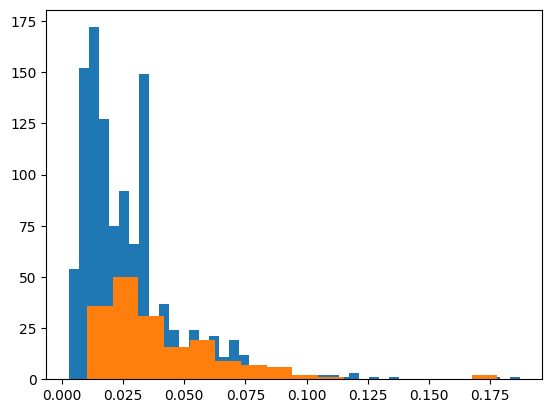

In [23]:
plt.hist(ID_BI, bins="auto")
plt.hist(OOD_BI, bins="auto")

In [24]:
ID_Beta = get_Beta(X, models)
OOD_Beta = get_Beta(X_OOD, models)

In [25]:
ID_Beta.mean()

0.0469571136827774

In [26]:
OOD_Beta.mean()

0.14177051998281048

(array([92., 16., 12.,  4.,  3., 12.,  8., 10., 22.]),
 array([0.00769231, 0.05726496, 0.10683761, 0.15641026, 0.20598291,
        0.25555556, 0.30512821, 0.35470085, 0.4042735 , 0.45384615]),
 <BarContainer object of 9 artists>)

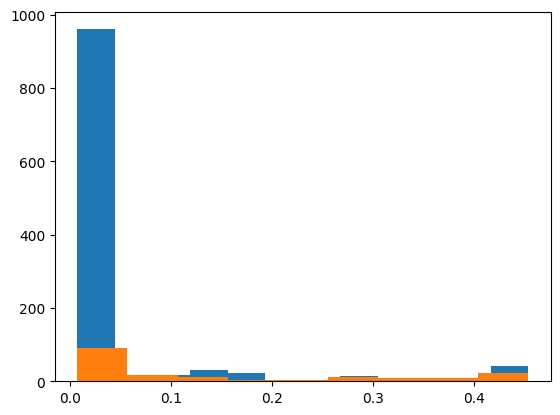

In [27]:
plt.hist(ID_Beta, bins="auto")
plt.hist(OOD_Beta, bins="auto")

In [28]:
tracin_ID_1 = get_random_tracin(X_test=X[np.random.choice(len(X), 200, replace=False)], y_test=1, X_train=X, y_train=y, mlp=models[0], n_iter=20, batch_size=200)
tracin_ID_0 = get_random_tracin(X_test=X[np.random.choice(len(X), 200, replace=False)], y_test=0, X_train=X, y_train=y, mlp=models[0], n_iter=20, batch_size=200)
tracin_ID = tracin_ID_0 + tracin_ID_1

In [29]:
tracin_ID

array([[ 0.62335974,  0.68667474,  0.79020034, ...,  0.1051352 ,
         0.1868822 ,  0.1859445 ],
       [ 1.29992455,  1.33695036,  1.43069899, ...,  0.79041556,
         0.31300816,  0.82660183],
       [ 0.62389302,  0.69393989,  0.79039615, ...,  0.6559329 ,
         0.65450722,  0.6419487 ],
       ...,
       [ 0.94198471,  0.9698713 ,  1.06251222, ..., -0.22254102,
        -0.7014394 ,  0.09838729],
       [ 0.23970264,  0.36358869,  0.49470073, ...,  0.32213646,
         0.3108274 ,  0.30076703],
       [ 0.81725755,  0.84527457,  0.93793474, ..., -0.34761882,
        -0.82650307, -0.02657366]])

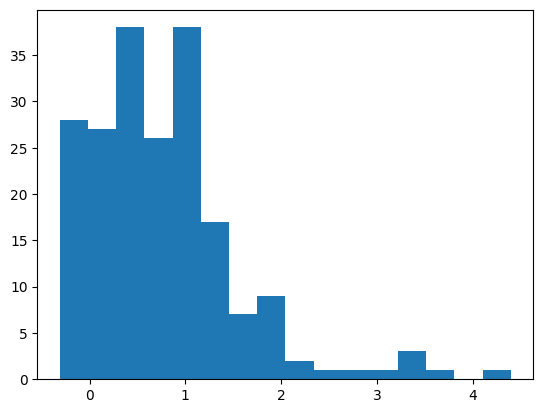

In [30]:
plt.hist(tracin_ID.T[0], bins="auto")
plt.show()

In [ ]:
tracin_OOD_1 = get_random_tracin(X_test=X_OOD[np.random.choice(len(X_OOD), 200, replace=False)], y_test=1, X_train=X, y_train=y, mlp=models[0], n_iter=20, batch_size=200)
tracin_OOD_0 = get_random_tracin(X_test=X_OOD[np.random.choice(len(X_OOD), 200, replace=False)], y_test=0, X_train=X, y_train=y, mlp=models[0], n_iter=20, batch_size=200)
tracin_OOD = tracin_OOD_0 + tracin_OOD_1

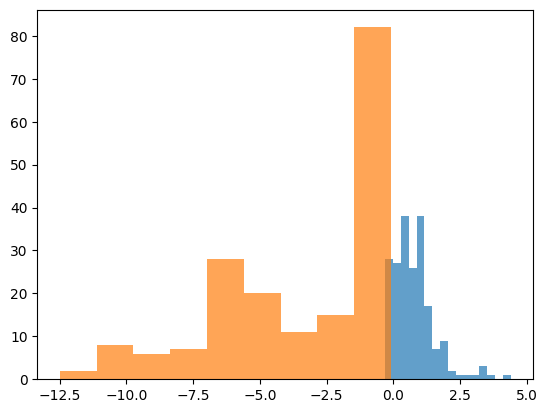

In [32]:
plt.hist(tracin_ID.T[0], bins="auto", alpha=0.7)
plt.hist(tracin_OOD.T[0], bins="auto", alpha=0.7)
plt.show()

In [82]:
mask = (full["Sex"] == "male") & (full["Survived"] == 1)
OOD = full[mask]

In [83]:
len(OOD)

109

In [84]:
y_OOD = OOD["Pclass"]
features = ["Survived", "Sex", "Age", "SibSp", "Parch", "Embarked"]
X_OOD = pd.get_dummies(OOD[features], dtype="float")

X_OOD["Age"] = X_OOD["Age"].fillna(X_OOD["Age"].mean())
X_OOD["Survived"] = X_OOD["Survived"].fillna(0)

In [85]:
X_OOD = np.hstack((X_OOD.to_numpy()[:,:-1], np.zeros((X_OOD.shape[0], 1))))
y_OOD = y_OOD.to_numpy()

y_OOD = np.eye(3)[y_OOD - 1]

In [86]:
ID = full[~mask]

y_ID = ID["Pclass"]
features = ["Survived", "Sex", "Age", "SibSp", "Parch", "Embarked"]
X_ID = pd.get_dummies(ID[features], dtype="float")

X_ID["Age"] = X_ID["Age"].fillna(X_ID["Age"].mean())
X_ID["Survived"] = X_ID["Survived"].fillna(0)

In [87]:
#X_ID = np.hstack((X_ID.to_numpy()[:,:-1], np.ones((X_ID.shape[0], 1))))
X_ID = X_ID.drop("Sex_male", axis=1).to_numpy()
y_ID = y_ID.to_numpy()

y_ID = np.eye(3)[y_ID - 1]

In [88]:
classifier = MLP(in_channels=8, hidden_channels=[30, 100, 200, 100, 50, 3], patience=5, frequency=3, lr=1e-2, device="mps")

In [89]:
models = bootstrap(classifier, X_ID, y_ID, 64)

In [64]:
ID_BI = get_BI(X_ID, models)
OOD_BI = get_BI(X_OOD, models)

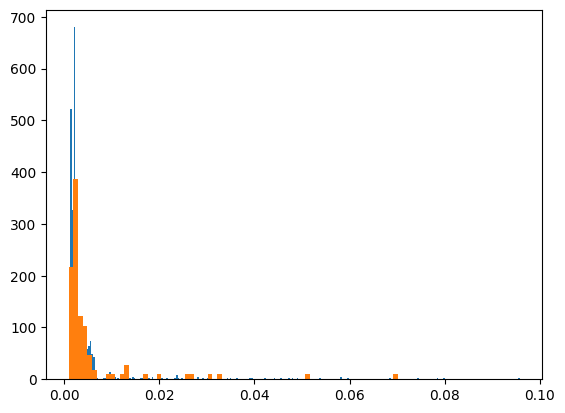

In [74]:
plt.hist(ID_BI, bins="auto", density=True)
plt.hist(OOD_BI, bins="auto", density=True)
plt.show()

In [66]:
ID_dirichlet = get_dirichlet(X_ID, models)
OOD_dirichlet = get_dirichlet(X_OOD, models)

In [67]:
ID_dirichlet

array([0.01526718, 0.03053435, 0.01526718, ..., 0.01526718, 0.01526718,
       0.01526718])

(array([55.,  0.,  0.,  0., 43.,  0.,  0., 11.]),
 array([0.01526718, 0.01908397, 0.02290076, 0.02671756, 0.03053435,
        0.03435115, 0.03816794, 0.04198473, 0.04580153]),
 <BarContainer object of 8 artists>)

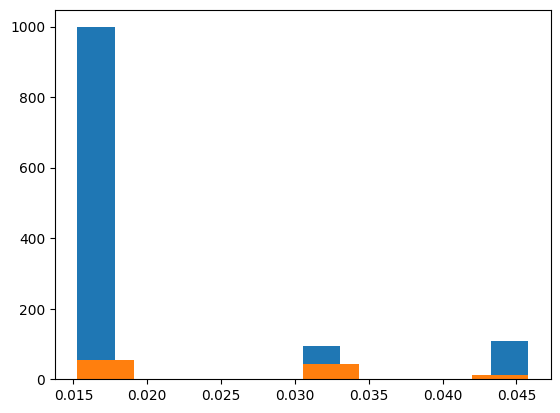

In [68]:
plt.hist(ID_dirichlet, bins="auto")
plt.hist(OOD_dirichlet, bins="auto")

In [112]:
models = bootstrap(classifier, X_ID, y_ID, 1)
n_iter=20
b_size = 100


In [110]:
len(OOD)

109

In [ ]:
tracin_ID_0 = get_random_tracin(X_test=X_ID[np.random.choice(len(X_ID), 100, replace=False)], y_test=np.eye(3)[0], X_train=X_ID, y_train=y_ID, mlp=models[0], n_iter=n_iter, batch_size=b_size)
tracin_ID_1 = get_random_tracin(X_test=X_ID[np.random.choice(len(X_ID), 100, replace=False)], y_test=np.eye(3)[1], X_train=X_ID, y_train=y_ID, mlp=models[0], n_iter=n_iter, batch_size=b_size)
tracin_ID_2 = get_random_tracin(X_test=X_ID[np.random.choice(len(X_ID), 100, replace=False)], y_test=np.eye(3)[2], X_train=X_ID, y_train=y_ID, mlp=models[0], n_iter=n_iter, batch_size=b_size)
tracin_ID = tracin_ID_0 + tracin_ID_1 +tracin_ID_2

(array([ 2., 11., 27., 18., 19.,  7.,  4.,  2.,  0.,  5.,  1.,  0.,  0.,
         1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  0.,  0.,
         0.,  0.,  1.]),
 array([-0.29537383, -0.18989753, -0.08442122,  0.02105508,  0.12653138,
         0.23200769,  0.33748399,  0.44296029,  0.5484366 ,  0.6539129 ,
         0.7593892 ,  0.86486551,  0.97034181,  1.07581811,  1.18129442,
         1.28677072,  1.39224702,  1.49772333,  1.60319963,  1.70867594,
         1.81415224,  1.91962854,  2.02510485,  2.13058115,  2.23605745,
         2.34153376,  2.44701006,  2.55248636,  2.65796267,  2.76343897]),
 <BarContainer object of 29 artists>)

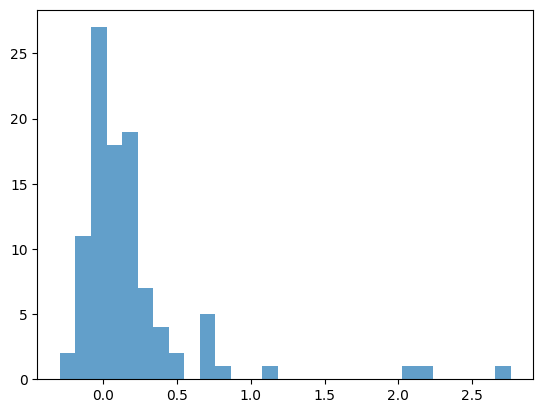

In [93]:
plt.hist(tracin_ID.T[-1], bins="auto", alpha=0.7)

In [ ]:
tracin_OOD_0 = get_random_tracin(X_test=X_OOD[np.random.choice(len(X_OOD), 100, replace=False)], y_test=np.eye(3)[0], X_train=X_ID, y_train=y_ID, mlp=models[0], n_iter=n_iter, batch_size=b_size)
tracin_OOD_1 = get_random_tracin(X_test=X_OOD[np.random.choice(len(X_OOD), 100, replace=False)], y_test=np.eye(3)[1], X_train=X_ID, y_train=y_ID, mlp=models[0], n_iter=n_iter, batch_size=b_size)
tracin_OOD_2 = get_random_tracin(X_test=X_OOD[np.random.choice(len(X_OOD), 100, replace=False)], y_test=np.eye(3)[2], X_train=X_ID, y_train=y_ID, mlp=models[0], n_iter=n_iter, batch_size=b_size)
tracin_OOD = tracin_OOD_0 + tracin_OOD_1 +tracin_OOD_2

(array([ 4., 15., 37., 14.,  6.,  4.,  5.,  2.,  1.,  2.,  0.,  1.,  2.,
         2.,  1.,  2.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-0.16791654, -0.06992331,  0.02806991,  0.12606313,  0.22405635,
         0.32204958,  0.4200428 ,  0.51803602,  0.61602924,  0.71402247,
         0.81201569,  0.91000891,  1.00800213,  1.10599536,  1.20398858,
         1.3019818 ,  1.39997502,  1.49796825,  1.59596147,  1.69395469,
         1.79194792,  1.88994114,  1.98793436,  2.08592758,  2.18392081,
         2.28191403,  2.37990725]),
 <BarContainer object of 26 artists>)

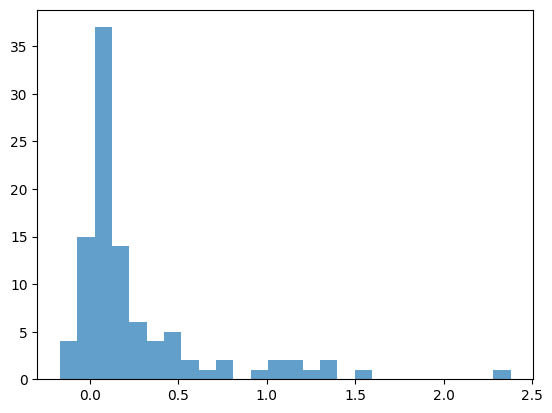

In [95]:
plt.hist(tracin_OOD.T[-1], bins="auto", alpha=0.7)

## Male OOD

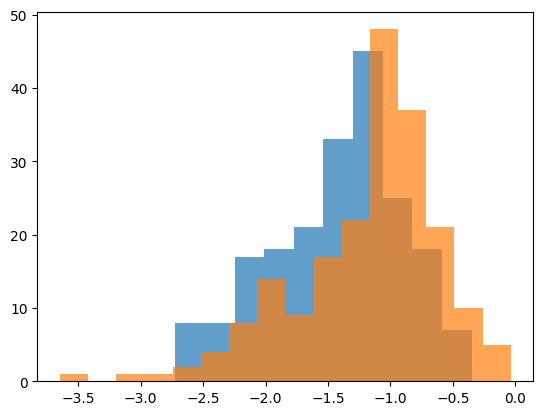

In [34]:
plt.hist(tracin_ID.T[0], bins="auto", alpha=0.7)
plt.hist(tracin_OOD.T[0], bins="auto", alpha=0.7)
plt.show()

## Male survived OOD

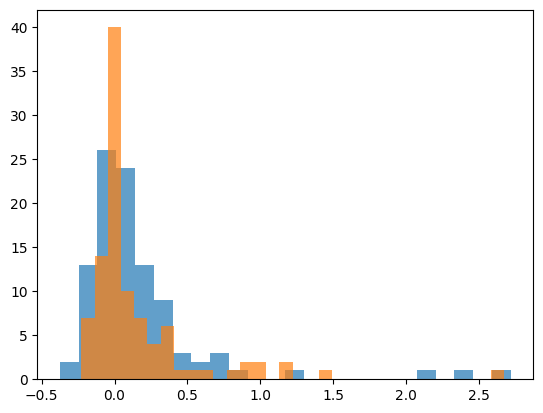

In [108]:
n= 14
plt.hist(tracin_ID.T[n], bins="auto", alpha=0.7)
plt.hist(tracin_OOD.T[n], bins="auto", alpha=0.7)
plt.show()

In [45]:

from sklearn.inspection._plot.decision_boundary import _check_boundary_response_method

_check_boundary_response_method(models[62], "predict_proba")(X)

RuntimeError: linear(): input and weight.T shapes cannot be multiplied (1130x6 and 8x30)

In [ ]:
preds = np.array([_check_boundary_response_method(m, "predict_proba")(X_OOD) for m in models])

In [ ]:
preds.shape

(64, 277)

In [ ]:
from ppu.methods.utils import LSE, LSE_LB_estimator_, stable_logit_transform
logits = stable_logit_transform(preds)

In [ ]:
logits.shape

(64, 277)

In [ ]:
logits.T[5]

array([-1.0036604 , -4.608194  , -2.6083894 , -0.7004416 , -5.517229  ,
       -1.0701258 , -0.86810374, -1.0943935 , -1.0949719 , -1.3014778 ,
       -0.6427033 , -0.6004249 , -1.0681231 , -1.073679  , -0.8009491 ,
       -1.0522633 , -0.832     , -4.9961505 , -1.0515301 , -0.9982729 ,
       -0.7594031 , -1.040648  , -0.81147397, -5.1654315 , -5.0584555 ,
       -2.9242263 , -1.0376065 , -1.0840757 , -1.0711871 , -4.8759103 ,
       -1.1140587 , -0.9953344 , -0.8617044 , -1.0770384 , -1.0536811 ,
       -4.0530667 , -1.0636212 , -0.77665657, -1.0555537 , -1.0659277 ,
       -5.232614  , -4.2297115 , -1.0575688 , -3.7764065 , -5.4067698 ,
       -3.9857028 , -2.435553  , -0.7955644 , -1.1147698 , -1.0855397 ,
       -1.0570018 , -0.6413331 , -0.8326261 , -1.0430157 , -2.9232242 ,
       -1.0058503 , -1.0832386 , -0.54981923, -1.0729384 , -1.0656778 ,
       -0.97402555, -1.0558708 , -1.0622301 , -0.4807402 ], dtype=float32)